# Paper Results Tables and Figures

This notebook collects experiment results and generates paper-ready  tables / figures.


## 1. Imports and Global Settings

In [1]:
from collections import defaultdict
from pathlib import Path
import csv
import math
import json

import numpy as np
import matplotlib.pyplot as plt

def find_repo_root(start=None):
    start = Path.cwd() if start is None else Path(start).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "eval_script.py").exists() and (candidate / "eval_experiments").exists():
            return candidate
    raise RuntimeError("Could not locate UCMEC repo root from the current working directory.")

REPO_ROOT = find_repo_root()
OUTPUT_ROOT = REPO_ROOT / "eval_experiments" / "outputs"

# Change this timestamp when using another sweep output.
SWEEP_RUN = "20260604_141550"
SWEEP_CSV = OUTPUT_ROOT / "sweep_outputs" / SWEEP_RUN / "eval_sweep_results.csv"
SWEEP_JSONL = OUTPUT_ROOT / "sweep_outputs" / SWEEP_RUN / "eval_sweep_results.jsonl"

TABLE_DIR = OUTPUT_ROOT / "paper_results" / "generated_tables"
FIGURE_DIR = OUTPUT_ROOT / "paper_results" / "generated_figures"
TABLE_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

DEFAULT_ENV = {"m_sim": 10, "n_sim": 50, "epsilon": 3e-3}

METHOD_LABELS = {
    "Proposed_HDRL": "Proposed HDRL",
    "FlatDRL": "Flat DRL",
    "AccessGreedy": "Access-Greedy",
    "FrontGreedyTopL": "Fronthaul-Greedy",
    "MaxPower": "HDRL Max Power",
    "MinPower": "HDRL Min Power",
}

MAIN_TABLE_LABELS = {
    "Proposed_HDRL": "Proposed",
    "FlatDRL": "Flat DRL",
    "AccessGreedy": "Access-G",
    "FrontGreedyTopL": "FH-G",
    "MaxPower": "Max Power",
    "MinPower": "Min Power",
}

METHOD_ORDER_MAIN = [
    "Proposed_HDRL",
    "FlatDRL",
    "AccessGreedy",
    "FrontGreedyTopL",
    "MaxPower",
    "MinPower",
]

MAIN_TABLE_METRICS = [
    ("avg_total_delay_ms", "Total Delay (ms)", "min", 1.0, 2),
    ("avg_offloading_users", "Offloading Ratio (%)", "max", 10.0, 1),
    ("avg_uplink_delay_ms", "Access Delay (ms)", "min", 1.0, 2),
    ("avg_front_delay_ms", "Fronthaul Delay (ms)", "min", 1.0, 2),
    ("avg_actual_process_delay_ms", "Edge Delay (ms)", "min", 1.0, 2),
    ("avg_local_delay_ms", "Local Delay (ms)", "min", 1.0, 2),
]

METRICS = [(key, label, direction) for key, label, direction, _, _ in MAIN_TABLE_METRICS]

## 2. Utility Functions

In [2]:
def _to_number(value):
    if value is None:
        return value
    try:
        if isinstance(value, str) and value.strip() == "":
            return value
        x = float(value)
        if x.is_integer():
            return int(x)
        return x
    except (TypeError, ValueError):
        return value


def load_csv_records(path):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(path)
    with path.open(newline="") as f:
        reader = csv.DictReader(f)
        return [{k: _to_number(v) for k, v in row.items()} for row in reader]


def load_jsonl_summary_records(path):
    """Load eval_sweep JSONL and flatten payload.summary into table-friendly rows."""
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(path)

    records = []
    with path.open() as f:
        for line in f:
            if not line.strip():
                continue
            raw = json.loads(line)
            payload = raw.get("payload", {})
            env = payload.get("env", {})
            summary = payload.get("summary", {})

            row = {
                "method": raw.get("method"),
                "run": raw.get("run"),
                "name": raw.get("name"),
                "sweep": raw.get("sweep"),
                "value": _to_number(raw.get("value")),
                "cached": bool(raw.get("cached", False)),
                "m_sim": _to_number(env.get("m_sim")),
                "n_sim": _to_number(env.get("n_sim")),
                "epsilon": _to_number(env.get("epsilon")),
            }
            row.update(summary)
            records.append(row)
    return records


def is_default_row(row, default=DEFAULT_ENV, tol=1e-12):
    return (
        int(row["m_sim"]) == default["m_sim"]
        and int(row["n_sim"]) == default["n_sim"]
        and abs(float(row["epsilon"]) - default["epsilon"]) < tol
    )


def dedupe_env_rows(rows):
    """Remove duplicate logical rows caused by default-point cache reuse across sweeps."""
    seen = set()
    out = []
    for row in rows:
        key = (row.get("method"), row.get("run"), row.get("m_sim"), row.get("n_sim"), row.get("epsilon"))
        if key in seen:
            continue
        seen.add(key)
        out.append(row)
    return out


def mean_se(values):
    arr = np.asarray(values, dtype=float)
    mean = float(np.mean(arr))
    if len(arr) <= 1:
        return mean, None
    se = float(np.std(arr, ddof=1) / math.sqrt(len(arr)))
    return mean, se


def aggregate_by_method(rows, metrics=METRICS):
    grouped = defaultdict(list)
    for row in rows:
        grouped[row["method"]].append(row)

    summary = {}
    for method, method_rows in grouped.items():
        summary[method] = {}
        for metric_key, _, _ in metrics:
            values = [float(r[f"{metric_key}_mean"]) for r in method_rows]
            summary[method][metric_key] = mean_se(values)
    return summary


def fmt_mean_se(mean, se, digits=2):
    if se is None:
        return f"{mean:.{digits}f}"
    return f"{mean:.{digits}f} $\\pm$ {se:.{digits}f}"


def bold(text):
    return f"\\textbf{{{text}}}"


def make_latex_table(summary, method_order, caption, label, metrics=METRICS, digits=2, bold_best=True):
    method_order = [m for m in method_order if m in summary]
    lines = []
    lines.append("\\begin{table}[t]")
    lines.append("\\centering")
    lines.append(f"\\caption{{{caption}}}")
    lines.append(f"\\label{{{label}}}")
    lines.append("\\renewcommand{\\arraystretch}{1.1}")
    col_spec = "l" + "c" * len(method_order)
    lines.append(f"\\begin{{tabular}}{{{col_spec}}}")
    lines.append("\\toprule")
    header = ["Metric"] + [METHOD_LABELS.get(m, m) for m in method_order]
    lines.append(" & ".join(header) + " \\")
    lines.append("\\midrule")

    for metric_key, metric_label, direction in metrics:
        means = {m: summary[m][metric_key][0] for m in method_order}
        if direction == "min":
            best_value = min(means.values())
        elif direction == "max":
            best_value = max(means.values())
        else:
            best_value = None

        row = [metric_label]
        for method in method_order:
            mean, se = summary[method][metric_key]
            cell = fmt_mean_se(mean, se, digits=digits)
            if bold_best and best_value is not None and abs(mean - best_value) < 1e-9:
                cell = bold(cell)
            row.append(cell)
        lines.append(" & ".join(row) + " \\")

    lines.append("\\bottomrule")
    lines.append("\\end{tabular}")
    lines.append("\\end{table}")
    return "\n".join(lines)


def save_text(path, text):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(text, encoding="utf-8")
    print(f"Saved {path}")

## 3. Load Sweep Results

In [3]:
sweep_rows = load_csv_records(SWEEP_CSV)
sweep_summary_rows = load_jsonl_summary_records(SWEEP_JSONL)

print(f"Loaded {len(sweep_rows)} CSV rows from {SWEEP_CSV}")
print(f"Loaded {len(sweep_summary_rows)} JSONL summary rows from {SWEEP_JSONL}")
print("Methods:", sorted({r["method"] for r in sweep_rows}))
print("Sweeps:", sorted({r["sweep"] for r in sweep_rows}))


Loaded 270 CSV rows from eval_experiments/outputs/sweep_outputs/20260604_141550/eval_sweep_results.csv
Loaded 270 JSONL summary rows from eval_experiments/outputs/sweep_outputs/20260604_141550/eval_sweep_results.jsonl
Methods: ['AccessGreedy', 'FlatDRL', 'FrontGreedyTopL', 'MaxPower', 'MinPower', 'Proposed_HDRL']
Sweeps: ['M_sim', 'N_sim', 'epsilon']


## 4. Main Result Table: Default Environment Performance

Default environment: \(M=10\), \(N=50\), and \(\epsilon=3\times 10^{-3}\). Duplicate default rows from different sweep dimensions are removed before aggregation.

This section displays the table values directly below the cell. No LaTeX table is exported.


In [4]:
from IPython.display import HTML, display


def fmt_table_value(mean, se, digits=2):
    if se is None:
        return f"{mean:.{digits}f}"
    return f"{mean:.{digits}f}±{se:.{digits}f}"


def build_main_result_table(rows):
    default_rows = dedupe_env_rows([r for r in rows if is_default_row(r)])
    summary = aggregate_by_method(default_rows)

    table = []
    for metric_key, metric_label, direction, scale, digits in MAIN_TABLE_METRICS:
        scaled_means = {
            method: summary[method][metric_key][0] * scale
            for method in METHOD_ORDER_MAIN
        }
        best_value = min(scaled_means.values()) if direction == "min" else max(scaled_means.values())

        row = {"Metric": metric_label}
        for method in METHOD_ORDER_MAIN:
            mean, se = summary[method][metric_key]
            mean *= scale
            se = None if se is None else se * scale
            value = fmt_table_value(mean, se, digits=digits)
            if abs(mean - best_value) < 1e-9:
                value = f"<b>{value}</b>"
            row[MAIN_TABLE_LABELS.get(method, method)] = value
        table.append(row)
    return table


def display_result_table(rows, columns):
    html = [
        "<table style='border-collapse:collapse; font-size:14px;'>",
        "<thead><tr>" + "".join(
            f"<th style='border-top:1.5px solid #555; border-bottom:1px solid #999; padding:7px 10px; text-align:center;'>{c}</th>"
            for c in columns
        ) + "</tr></thead>",
        "<tbody>",
    ]
    for row in rows:
        html.append("<tr>" + "".join(
            f"<td style='border-bottom:1px solid #bbb; padding:7px 10px; text-align:center;'>{row.get(c, '')}</td>"
            for c in columns
        ) + "</tr>")
    html.append("</tbody></table>")
    display(HTML("\n".join(html)))


main_result_table = build_main_result_table(sweep_summary_rows)
main_columns = ["Metric"] + [MAIN_TABLE_LABELS[m] for m in METHOD_ORDER_MAIN]
display_result_table(main_result_table, main_columns)


Metric,Proposed,Flat DRL,Access-G,FH-G,Max Power,Min Power
Total Delay (ms),153.42±2.03,205.68±3.34,227.16±0.32,162.22±0.55,161.73±1.51,160.51±2.49
Offloading Ratio (%),86.6±0.7,60.7±0.8,43.3±0.2,83.4±0.2,86.5±1.1,86.3±0.3
Access Delay (ms),46.37±3.56,22.86±1.68,11.96±0.40,61.92±0.39,57.91±0.24,54.59±2.35
Fronthaul Delay (ms),34.58±0.50,67.98±2.54,55.78±0.38,24.69±0.66,33.48±1.73,35.43±1.45
Edge Delay (ms),47.30±0.44,35.57±1.02,28.85±0.21,47.05±0.12,48.53±0.14,47.88±0.10
Local Delay (ms),203.66±7.23,314.10±1.11,320.11±0.19,235.94±1.48,203.92±13.36,208.29±1.47


## 5. Figures: Sensitivity Curves from Sweep Results

These plots aggregate the three trained runs of each method at each sweep value.

In [5]:
METHOD_COLORS = {
    "Proposed_HDRL": "#0000ff",
    "FlatDRL": "#d6275b",
    "AccessGreedy": "#ff7f0e",
    "FrontGreedyTopL": "#008b8b",
    "MaxPower": "#ff0000",
    "MinPower": "#000000",
}
METHOD_MARKERS = {
    "Proposed_HDRL": "o",
    "FlatDRL": "s",
    "AccessGreedy": "^",
    "FrontGreedyTopL": "d",
    "MaxPower": "x",
    "MinPower": "*",
}
METHOD_LINESTYLES = {
    "Proposed_HDRL": "-",
    "FlatDRL": "-",
    "AccessGreedy": "-",
    "FrontGreedyTopL": "-",
    "MaxPower": "-",
    "MinPower": "--",
}


def aggregate_sweep(rows, sweep_name, metric_key="avg_total_delay_ms"):
    values = defaultdict(list)
    for row in rows:
        if row["sweep"] != sweep_name:
            continue
        x_value = float(row["value"])
        if sweep_name == "epsilon":
            x_value *= 1000
        values[(row["method"], x_value)].append(float(row[f"{metric_key}_mean"]))

    out = defaultdict(list)
    for (method, value), vals in values.items():
        mean, se = mean_se(vals)
        out[method].append((value, mean, se))
    for method in out:
        out[method] = sorted(out[method], key=lambda x: x[0])
    return out


def plot_sweep_curve(
    sweep_name,
    xlabel,
    output_name,
    method_order=METHOD_ORDER_MAIN,
    metric_key="avg_total_delay_ms",
    xlim=None,
    ylim=None,
    xticks=None,
    yticks=None,
):
    data = aggregate_sweep(sweep_rows, sweep_name, metric_key=metric_key)
    fig, ax = plt.subplots(figsize=(7.2, 4.8))
    for method in method_order:
        if method not in data:
            continue
        xs = [x for x, _, _ in data[method]]
        ys = [y for _, y, _ in data[method]]
        ax.plot(
            xs,
            ys,
            label=METHOD_LABELS.get(method, method),
            color=METHOD_COLORS.get(method),
            marker=METHOD_MARKERS.get(method, "o"),
            linestyle=METHOD_LINESTYLES.get(method, "-"),
            linewidth=1.25,
            markersize=5,
            markeredgewidth=1.0,
        )
    ax.set_xlabel(xlabel, fontsize=13)
    ax.set_ylabel("Average Total Delay (ms)", fontsize=13)
    ax.tick_params(axis="both", labelsize=11)
    if xlim is not None:
        ax.set_xlim(*xlim)
    if ylim is not None:
        ax.set_ylim(*ylim)
    if xticks is not None:
        ax.set_xticks(xticks)
    if yticks is not None:
        ax.set_yticks(yticks)
    ax.grid(True, alpha=0.35)
    ax.legend(fontsize=10)
    fig.tight_layout()
    png_path = FIGURE_DIR / f"{output_name}.png"
    pdf_path = FIGURE_DIR / f"{output_name}.pdf"
    fig.savefig(png_path, dpi=240)
    fig.savefig(pdf_path)
    plt.show()
    print(f"Saved {png_path}")
    print(f"Saved {pdf_path}")

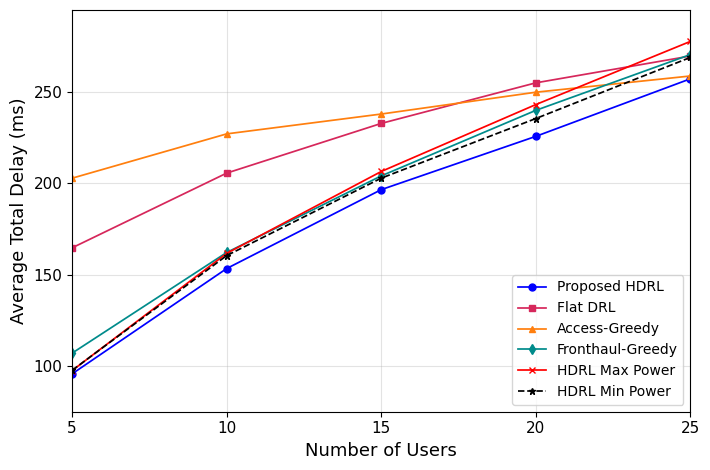

Saved eval_experiments/outputs/paper_results/generated_figures/sweep_users_total_delay.png
Saved eval_experiments/outputs/paper_results/generated_figures/sweep_users_total_delay.pdf


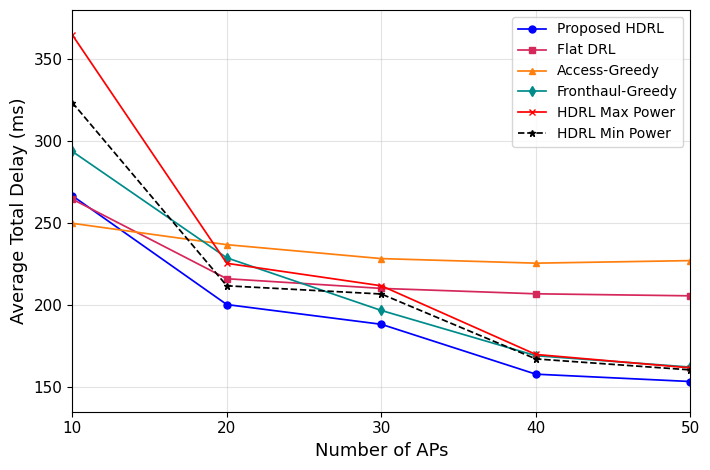

Saved eval_experiments/outputs/paper_results/generated_figures/sweep_aps_total_delay.png
Saved eval_experiments/outputs/paper_results/generated_figures/sweep_aps_total_delay.pdf


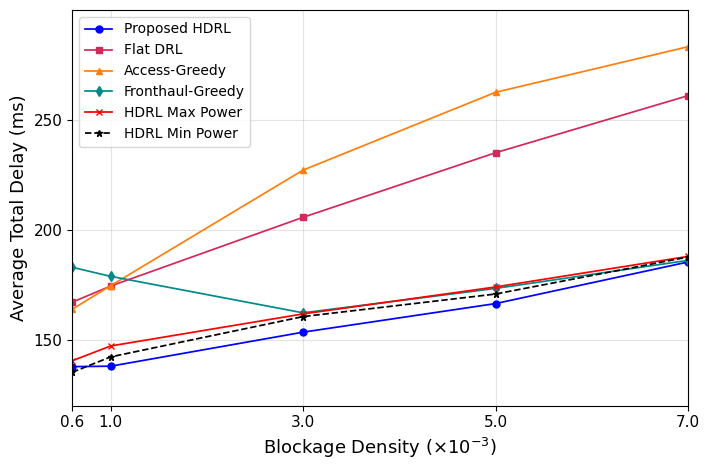

Saved eval_experiments/outputs/paper_results/generated_figures/sweep_blockage_total_delay.png
Saved eval_experiments/outputs/paper_results/generated_figures/sweep_blockage_total_delay.pdf


In [6]:
plot_sweep_curve(
    "M_sim",
    "Number of Users",
    "sweep_users_total_delay",
    xlim=(5, 25),
    ylim=(75, 295),
    xticks=[5, 10, 15, 20, 25],
    yticks=[100, 150, 200, 250],
)
plot_sweep_curve(
    "N_sim",
    "Number of APs",
    "sweep_aps_total_delay",
    xlim=(10, 50),
    ylim=(135, 380),
    xticks=[10, 20, 30, 40, 50],
    yticks=[150, 200, 250, 300, 350],
)

plot_sweep_curve(
    "epsilon",
    r"Blockage Density ($\times 10^{-3}$)",
    "sweep_blockage_total_delay",
    xlim=(0.6, 7),
    ylim=(120, 300),
    xticks=[0.6, 1, 3, 5, 7],
    yticks=[150, 200, 250],
)


## 6. Load Ablation Results



In [8]:
ABLATION_RUN = "20260605_000221"
ABLATION_DIR = OUTPUT_ROOT / "ablation_outputs" / ABLATION_RUN
ABLATION_CSV = ABLATION_DIR / "ablation_results.csv"
ABLATION_JSONL = ABLATION_DIR / "ablation_results.jsonl"


def load_ablation_jsonl_summary_records(path):
    """Load ablation JSONL and flatten payload.summary into row dictionaries."""
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(path)

    records = []
    with path.open(encoding="utf-8") as f:
        for line in f:
            if not line.strip():
                continue

            raw = json.loads(line)
            payload = raw.get("payload", {})
            env = payload.get("env", {})
            mode = payload.get("mode", {})
            summary = payload.get("summary", {})

            row = {
                "group": raw.get("group"),
                "variant": raw.get("variant"),
                "run": raw.get("run"),
                "name": raw.get("name"),
                "m_sim": _to_number(env.get("m_sim")),
                "n_sim": _to_number(env.get("n_sim")),
                "epsilon": _to_number(env.get("epsilon")),
                "candidate_n": _to_number(env.get("candidate_n")),
                "k_fixed": _to_number(env.get("k_fixed")),
                "high_action_dim": _to_number(env.get("high_action_dim")),
                "high_policy_mode": mode.get("high_policy_mode"),
                "use_hierarchical": mode.get("use_hierarchical"),
            }
            row.update(summary)
            records.append(row)

    return records


ablation_rows = load_ablation_jsonl_summary_records(ABLATION_JSONL)

print(f"Loaded {len(ablation_rows)} ablation rows from {ABLATION_JSONL}")
print("Groups / variants:")
for group, variant in sorted({(r["group"], r["variant"]) for r in ablation_rows}):
    count = sum(1 for r in ablation_rows if r["group"] == group and r["variant"] == variant)
    print(f"  {group:16s} {variant:28s} {count} runs")


# =========================
# Labels
# =========================

ABLATION_LABELS = {
    "candidate5": "Candidate-5",
    "candidate8": "Candidate-8",
    "candidate12": "Candidate-12",
    "candidate15": "Candidate-15",
    "cluster1": "Access-G Cluster-1",
    "cluster3": "Access-G Cluster-3",
    "cluster1_blockage7e-3": "Access-G Cluster-1",
    "without_pair_scorer": "HDRL w/o Pair Scorer",
    "without_pair_interaction": "HDRL w/o Pair Interaction",
    "without_front_obs": "w/o FrontObs",
}


# =========================
# Filtering Helpers
# =========================

def filter_ablation_rows(group=None, variant=None, rows=ablation_rows):
    out = rows
    if group is not None:
        out = [r for r in out if r["group"] == group]
    if variant is not None:
        out = [r for r in out if r["variant"] == variant]
    return out


def filter_main_rows(method, rows=sweep_summary_rows, default=True, sweep=None, value=None, tol=1e-12):
    """Select rows from the main sweep JSONL records.

    default=True selects the default environment and removes duplicate default rows
    reused across different sweep dimensions.
    """
    out = [r for r in rows if r["method"] == method]

    if default:
        out = dedupe_env_rows([r for r in out if is_default_row(r)])
        return out

    if sweep is not None:
        out = [r for r in out if r["sweep"] == sweep]

    if value is not None:
        out = [r for r in out if abs(float(r["value"]) - float(value)) < tol]

    return out


# =========================
# Summary Helpers
# =========================

def summarize_result_rows(rows, metric_specs=MAIN_TABLE_METRICS):
    """Aggregate run-level means into mean ± SE across trained runs."""
    if len(rows) == 0:
        raise ValueError("No rows to summarize.")

    summary = {}
    for metric_key, metric_label, direction, scale, digits in metric_specs:
        col = f"{metric_key}_mean"
        values = [float(r[col]) for r in rows]
        mean, se = mean_se(values)
        summary[metric_key] = {
            "label": metric_label,
            "direction": direction,
            "scale": scale,
            "digits": digits,
            "mean": mean,
            "se": se,
        }
    return summary


def summarize_main_method(method, default=True, sweep=None, value=None):
    rows = filter_main_rows(method, default=default, sweep=sweep, value=value)
    return summarize_result_rows(rows)


def summarize_ablation_variant(group, variant):
    rows = filter_ablation_rows(group=group, variant=variant)
    return summarize_result_rows(rows)


def fmt_summary_cell(summary, metric_key):
    item = summary[metric_key]
    mean = item["mean"] * item["scale"]
    se = None if item["se"] is None else item["se"] * item["scale"]
    return fmt_table_value(mean, se, digits=item["digits"])


def build_summary_table(method_summaries, metric_specs=MAIN_TABLE_METRICS, bold_best=True):
    """Build display-ready rows from {column_label: summary_dict}."""
    table = []

    for metric_key, metric_label, direction, scale, digits in metric_specs:
        row = {"Metric": metric_label}

        scaled_means = {
            col: summary[metric_key]["mean"] * scale
            for col, summary in method_summaries.items()
        }
        best_value = min(scaled_means.values()) if direction == "min" else max(scaled_means.values())

        for col, summary in method_summaries.items():
            value = fmt_summary_cell(summary, metric_key)
            if bold_best and abs(scaled_means[col] - best_value) < 1e-9:
                value = f"<b>{value}</b>"
            row[col] = value

        table.append(row)

    return table


def display_summary_table(method_summaries, metric_specs=MAIN_TABLE_METRICS, bold_best=True):
    table = build_summary_table(method_summaries, metric_specs=metric_specs, bold_best=bold_best)
    columns = ["Metric"] + list(method_summaries.keys())
    display_result_table(table, columns)

Loaded 30 ablation rows from eval_experiments/outputs/ablation_outputs/20260605_000221/ablation_results.jsonl
Groups / variants:
  candidate_size   candidate12                  3 runs
  candidate_size   candidate15                  3 runs
  candidate_size   candidate5                   3 runs
  candidate_size   candidate8                   3 runs
  cluster_size     cluster1                     3 runs
  cluster_size     cluster1_blockage7e-3        3 runs
  cluster_size     cluster3                     3 runs
  high_ablation    without_pair_interaction     3 runs
  high_ablation    without_pair_scorer          3 runs
  low_ablation     without_front_obs            3 runs


## 7 cluster size table

In [10]:
cluster_size_summaries = {
    "Proposed HDRL": summarize_main_method("Proposed_HDRL"),
    "Access-G Cluster-1": summarize_ablation_variant("cluster_size", "cluster1"),
    "Access-G Cluster-2": summarize_main_method("AccessGreedy"),
    "Access-G Cluster-3": summarize_ablation_variant("cluster_size", "cluster3"),
}

display_summary_table(cluster_size_summaries)

Metric,Proposed HDRL,Access-G Cluster-1,Access-G Cluster-2,Access-G Cluster-3
Total Delay (ms),153.42±2.03,159.23±0.97,227.16±0.32,268.74±0.28
Offloading Ratio (%),86.6±0.7,74.5±0.4,43.3±0.2,25.0±0.1
Access Delay (ms),46.37±3.56,25.90±0.49,11.96±0.40,7.17±0.17
Fronthaul Delay (ms),34.58±0.50,34.73±0.35,55.78±0.38,60.48±0.39
Edge Delay (ms),47.30±0.44,40.45±0.24,28.85±0.21,20.42±0.16
Local Delay (ms),203.66±7.23,288.82±0.89,320.11±0.19,321.83±0.07


## 8 cluster size1 blockage density table

In [11]:
def get_metric_mean(summary, metric_key):
    item = summary[metric_key]
    return item["mean"] * item["scale"]


blockage3_proposed = summarize_main_method("Proposed_HDRL")
blockage3_cluster1 = summarize_ablation_variant("cluster_size", "cluster1")

blockage7_proposed = summarize_main_method(
    "Proposed_HDRL",
    default=False,
    sweep="epsilon",
    value=0.007,
)
blockage7_cluster1 = summarize_ablation_variant(
    "cluster_size",
    "cluster1_blockage7e-3",
)

blockage_rows = []

for label, proposed_summary, cluster1_summary in [
    (r"$\epsilon=3\times10^{-3}$", blockage3_proposed, blockage3_cluster1),
    (r"$\epsilon=7\times10^{-3}$", blockage7_proposed, blockage7_cluster1),
]:
    proposed_delay = get_metric_mean(proposed_summary, "avg_total_delay_ms")
    cluster1_delay = get_metric_mean(cluster1_summary, "avg_total_delay_ms")
    delay_reduction = cluster1_delay - proposed_delay

    blockage_rows.append({
        "Blockage Density": label,
        "Proposed HDRL": fmt_summary_cell(proposed_summary, "avg_total_delay_ms"),
        "Access-G Cluster-1": fmt_summary_cell(cluster1_summary, "avg_total_delay_ms"),
        "Delay Reduction": f"{delay_reduction:.2f} ms",
    })

display_result_table(
    blockage_rows,
    ["Blockage Density", "Proposed HDRL", "Access-G Cluster-1", "Delay Reduction"],
)

Blockage Density,Proposed HDRL,Access-G Cluster-1,Delay Reduction
$\epsilon=3\times10^{-3}$,153.42±2.03,159.23±0.97,5.81 ms
$\epsilon=7\times10^{-3}$,185.34±2.52,214.46±1.11,29.12 ms


## 9 high ablation table

In [9]:
method_summaries = {
    "Proposed HDRL": summarize_main_method("Proposed_HDRL"),
    "HDRL w/o Pair Scorer": summarize_ablation_variant("high_ablation", "without_pair_scorer"),
    "HDRL w/o Pair Interaction": summarize_ablation_variant("high_ablation", "without_pair_interaction"),
}

display_summary_table(method_summaries)

Metric,Proposed HDRL,HDRL w/o Pair Scorer,HDRL w/o Pair Interaction
Total Delay (ms),153.42±2.03,230.38±0.58,167.64±1.81
Offloading Ratio (%),86.6±0.7,46.6±0.3,87.1±0.5
Access Delay (ms),46.37±3.56,14.55±0.10,54.55±3.85
Fronthaul Delay (ms),34.58±0.50,75.23±1.44,43.47±2.97
Edge Delay (ms),47.30±0.44,29.92±0.08,49.09±0.97
Local Delay (ms),203.66±7.23,320.24±0.17,204.58±5.04


## 10 candidate size table

In [12]:
candidate_size_summaries = {
    "Candidate-5": summarize_ablation_variant("candidate_size", "candidate5"),
    "Candidate-8": summarize_ablation_variant("candidate_size", "candidate8"),
    "Candidate-10": summarize_main_method("Proposed_HDRL"),
    "Candidate-12": summarize_ablation_variant("candidate_size", "candidate12"),
    "Candidate-15": summarize_ablation_variant("candidate_size", "candidate15"),
}

display_summary_table(candidate_size_summaries)

Metric,Candidate-5,Candidate-8,Candidate-10,Candidate-12,Candidate-15
Total Delay (ms),169.62±1.47,158.54±1.44,153.42±2.03,175.39±4.00,186.38±6.85
Offloading Ratio (%),76.0±0.6,85.7±1.1,86.6±0.7,86.7±0.3,86.8±0.7
Access Delay (ms),18.75±0.59,42.10±3.91,46.37±3.56,75.87±4.63,96.78±9.42
Fronthaul Delay (ms),62.07±1.42,44.46±1.51,34.58±0.50,27.64±1.21,23.97±1.00
Edge Delay (ms),40.85±0.33,45.29±0.52,47.30±0.44,49.78±0.15,51.54±0.38
Local Delay (ms),275.00±2.84,215.19±14.45,203.66±7.23,204.04±4.78,198.22±4.25


## 11 low ablation table

In [13]:
low_ablation_summaries = {
    "Access-Greedy": summarize_main_method("AccessGreedy"),
    "w/o FrontObs": summarize_ablation_variant("low_ablation", "without_front_obs"),
}

display_summary_table(low_ablation_summaries)

Metric,Access-Greedy,w/o FrontObs
Total Delay (ms),227.16±0.32,284.25±1.12
Offloading Ratio (%),43.3±0.2,29.9±0.2
Access Delay (ms),11.96±0.40,8.86±0.14
Fronthaul Delay (ms),55.78±0.38,143.97±5.68
Edge Delay (ms),28.85±0.21,23.01±0.37
Local Delay (ms),320.11±0.19,312.97±1.58
